# CVL361: Python for Structural Programming

## Final Exam Project

### Simply Supported Beam Analysis

Student Name: Mohammed Walid

Student ID: 231000476

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Input Data

L = 8.0      # Beam span (m)
w = 6.0      # UDL (kN/m)
P = 18.0     # Point load (kN)
a = 5.0      # Distance from left support (m)

In [3]:
def calculate_reactions(L, w, P, a):

    W = w * L

    RB = (W * (L/2) + P * a) / L

    RA = W + P - RB

    return RA, RB


RA, RB = calculate_reactions(L, w, P, a)

print("Left Reaction RA =", RA, "kN")
print("Right Reaction RB =", RB, "kN")

Left Reaction RA = 30.75 kN
Right Reaction RB = 35.25 kN


In [5]:
def shear_force(x):

    if x < a:
        return RA - w * x

    else:
        return RA - w * x - P

In [6]:
def bending_moment(x):

    if x < a:
        return RA * x - (w * x**2) / 2

    else:
        return RA * x - (w * x**2) / 2 - P * (x - a)

In [7]:
x_values = np.linspace(0, L, 100)

V = [shear_force(x) for x in x_values]

M = [bending_moment(x) for x in x_values]

In [8]:
results = pd.DataFrame({
    "Position (m)": x_values,
    "Shear Force (kN)": V,
    "Bending Moment (kN.m)": M
})

results.head(15)

,Position (m),Shear Force (kN),Bending Moment (kN.m)
0,0.000000,30.750000,0.000000
1,0.080808,30.265152,2.465259
2,0.161616,29.780303,4.891338
3,0.242424,29.295455,7.278237
4,0.323232,28.810606,9.625957
5,0.404040,28.325758,11.934496
6,0.484848,27.840909,14.203857
7,0.565657,27.356061,16.434037
8,0.646465,26.871212,18.625038
9,0.727273,26.386364,20.776860


In [9]:
max_moment = max(M)

index = M.index(max_moment)

critical_location = x_values[index]

print("Maximum Bending Moment =", round(max_moment,2), "kN.m")

print("Location =", round(critical_location,2), "m")

Maximum Bending Moment = 78.68 kN.m
Location = 4.93 m


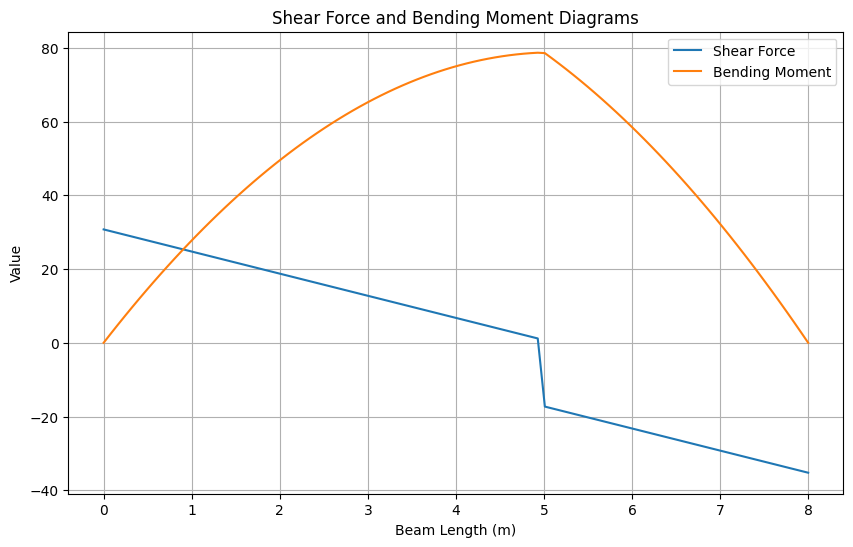

In [10]:
plt.figure(figsize=(10,6))

plt.plot(x_values, V, label="Shear Force")

plt.plot(x_values, M, label="Bending Moment")

plt.xlabel("Beam Length (m)")

plt.ylabel("Value")

plt.title("Shear Force and Bending Moment Diagrams")

plt.grid(True)

plt.legend()

plt.savefig("outputs/engineering_plot.png")

plt.show()

## Problem Statement

A simply supported beam of span 8 m is subjected to:

- Uniformly Distributed Load (UDL) = 6 kN/m over the entire span
- Point Load = 18 kN located 5 m from the left support

The objective is to calculate:

1. Support reactions
2. Shear force distribution
3. Bending moment distribution
4. Maximum bending moment
5. Critical section location

In [11]:
results.head(20)

,Position (m),Shear Force (kN),Bending Moment (kN.m)
0,0.000000,30.750000,0.000000
1,0.080808,30.265152,2.465259
2,0.161616,29.780303,4.891338
3,0.242424,29.295455,7.278237
4,0.323232,28.810606,9.625957
5,0.404040,28.325758,11.934496
6,0.484848,27.840909,14.203857
7,0.565657,27.356061,16.434037
8,0.646465,26.871212,18.625038
9,0.727273,26.386364,20.776860
